⚠️⚠️⚠️⚠️Before running this notebook you have to run **"CIC IoT Dataset 2023 - Preprocessed.ipynb"** notebook first then the **cleaned dataset** will be saved on the local directory by default under **"./dataset/cleaned_data"**

# Imports

In [1]:
import pandas as pd
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

RANDOM_STATE = 72

# Loading & Combine Dataset

I'm going to define the files' paths that contains my dataset first

In [2]:
data_directory = "./dataset/cleaned_data/"

parquet_files = glob.glob(os.path.join(data_directory, "*.parquet"))

if not parquet_files:
    print(f"No parquet files found in '{data_directory}'")

Now I'm going to read the actual data from these paths

In [3]:
dfs = []
for file in parquet_files:
    try:
        df_temp = pd.read_parquet(file)
        dfs.append(df_temp)
    except Exception as e:
        print(f"Error loading {file}: {e}")

In this stage I'll combine/concatenate data with each other to create one whole dataset

In [4]:
if dfs:
    df = pd.concat(dfs, ignore_index=True)
else:
    print("Something went wrong! coonfirm that data files are there.")

Ensuring data was successfully fetched

In [5]:
df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,-0.018025,-0.167425,-0.342900,-0.167212,-0.093112,-0.093112,-0.51562,1,0,1,...,-0.205885,-0.291610,0.011200,0.003291,-0.317348,-0.205716,-0.071405,-0.414431,0.003297,9
1,-0.018025,-0.167418,-0.305831,-0.167212,-0.093072,-0.093072,-0.51562,0,0,0,...,-0.188656,-0.279191,-0.013219,0.003291,-0.308990,-0.188409,-0.071046,-0.200851,0.003297,20
2,-0.018025,-0.167542,-0.904559,-0.167212,-0.092784,-0.092784,-0.51562,0,0,0,...,-0.205885,-0.340632,-0.001416,0.003291,-0.459093,-0.205716,-0.071405,-0.414431,0.003297,6
3,-0.017024,-0.001817,0.892748,-0.167212,-0.047055,-0.047055,-0.51562,0,0,0,...,-0.205885,-0.307950,-0.007980,0.003291,-0.362662,-0.205716,-0.071405,-0.414431,0.003297,21
4,-0.017667,-0.167321,-0.330544,-0.031029,-0.093053,-0.093053,-0.51562,0,1,0,...,-0.064825,-0.275759,-0.010476,0.003291,-0.207089,-0.064525,-0.064669,0.397172,0.003297,19


In [6]:
df.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
count,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,...,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07,4.033810e+07
mean,-4.992048e-03,6.676487e-17,3.071673e-06,3.632914e-03,-2.012246e-16,-2.012246e-16,-5.156199e-01,8.653173e-02,2.061319e-01,9.064591e-02,...,7.547751e-16,9.266202e-16,1.542290e-12,3.695993e-04,3.584997e-15,-5.204190e-16,-3.403856e-04,1.920176e-15,1.463100e-04,1.256502e+01
std,2.810067e-01,1.000000e+00,9.999972e-01,9.970237e-01,1.000000e+00,1.000000e+00,1.375023e-10,2.811476e-01,4.045263e-01,2.871049e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,9.974989e-01,1.000000e+00,1.000000e+00,9.049989e-01,1.000000e+00,9.991859e-01,5.863660e+00
min,-1.802532e-02,-1.675421e-01,-9.056824e-01,-2.713098e-01,-9.311503e-02,-9.311503e-02,-5.156199e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,-2.058847e-01,-3.406315e-01,-4.860359e+00,-4.863939e+00,-4.590932e-01,-2.057163e-01,-7.140548e-02,-4.144312e-01,-4.871947e+00,0.000000e+00
25%,-1.802532e-02,-1.674247e-01,-3.429005e-01,-1.672118e-01,-9.309427e-02,-9.309427e-02,-5.156199e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,-2.058847e-01,-3.079503e-01,-4.714214e-03,3.291182e-03,-3.626623e-01,-2.057163e-01,-7.140548e-02,-4.144312e-01,3.297124e-03,8.000000e+00
50%,-1.802532e-02,-1.674247e-01,-3.429005e-01,-1.672118e-01,-9.295787e-02,-9.295787e-02,-5.156199e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,-2.058847e-01,-2.916097e-01,-1.619138e-03,3.291182e-03,-3.173483e-01,-2.057163e-01,-7.140548e-02,-4.144312e-01,3.297124e-03,1.200000e+01
75%,-1.770642e-02,-1.668091e-01,5.692331e-01,-1.672118e-01,-9.193256e-02,-9.193256e-02,-5.156199e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,-2.035778e-01,-2.913646e-01,1.120356e-02,3.291182e-03,-3.168349e-01,-2.035329e-01,-7.140234e-02,-7.270350e-02,3.297124e-03,1.500000e+01
max,2.975839e+01,2.117434e+01,4.262700e+00,1.345108e+01,7.273642e+01,7.273642e+01,-5.156199e-01,1.000000e+00,1.000000e+00,1.000000e+00,...,6.690467e+01,5.299510e+01,4.938391e+00,6.087329e+00,1.245579e+01,6.690680e+01,2.252183e+02,3.857165e+00,4.878541e+00,3.300000e+01


In [7]:
df.columns

Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')

# Seperate Label from features

Dataframe Features and label information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40338103 entries, 0 to 40338102
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   Header_Length    float64
 2   Protocol Type    float64
 3   Duration         float64
 4   Rate             float64
 5   Srate            float64
 6   Drate            float64
 7   fin_flag_number  int64  
 8   syn_flag_number  int64  
 9   rst_flag_number  int64  
 10  psh_flag_number  int64  
 11  ack_flag_number  int64  
 12  ece_flag_number  int64  
 13  cwr_flag_number  int64  
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  HTTP             int64  
 20  HTTPS            int64  
 21  DNS              int64  
 22  Telnet           int64  
 23  SMTP             int64  
 24  SSH              int64  
 25  IRC              int64  
 26  TCP              int64  
 27  UDP       

Seperate features from the label

In [9]:
X = df.drop('label', axis=1)
y = df['label']

In [10]:
print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")

Features (X) shape: (40338103, 46)
Labels (y) shape: (40338103,)


# Splitting Dataset into Training and Test samples

Splitting the dataset into training and test datasets with 80% train and 20% test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

Let us see the splitting dataset shapes

In [12]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}\n")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (32270482, 46)
y_train shape: (32270482,)

X_test shape: (8067621, 46)
y_test shape: (8067621,)


Displaying current split to get more vision on what happened

In [13]:
X_train.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
33251973,-0.018025,-0.167542,-0.904559,-0.167212,-0.092943,-0.092943,-0.51562,0,0,0,...,-0.342766,-0.205885,-0.340632,-0.000161,0.003291,-0.459093,-0.205716,-0.071405,-0.414431,0.003297
33298627,-0.018025,-0.167542,-0.904559,-0.167212,-0.092999,-0.092999,-0.51562,0,0,0,...,-0.342766,-0.205885,-0.340632,-0.001375,0.003291,-0.459093,-0.205716,-0.071405,-0.414431,0.003297
34934776,-0.017947,-0.167534,-0.900066,-0.088782,-0.092155,-0.092155,-0.51562,0,0,0,...,-0.340785,-0.194671,-0.336628,-0.001164,0.003291,-0.453176,-0.194470,-0.071327,0.055444,0.003297
31792891,-0.018025,-0.167425,-0.342900,-0.167212,-0.092710,-0.092710,-0.51562,0,0,0,...,-0.293315,-0.205885,-0.291610,-0.006728,0.003291,-0.317348,-0.205716,-0.071405,-0.414431,0.003297
15756216,-0.018025,-0.167542,-0.904559,-0.167212,-0.093092,-0.093092,-0.51562,0,0,0,...,-0.342766,-0.205885,-0.340632,-0.001364,0.003291,-0.459093,-0.205716,-0.071405,-0.414431,0.003297


In [14]:
y_train.head()

,label
33251973,6
33298627,6
34934776,6
31792891,13
15756216,6


In [15]:
X_test.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
28331954,0.003303,-0.167171,-0.342900,-0.167212,-0.093109,-0.093109,-0.51562,0,0,1,...,-0.291493,-0.200152,-0.290139,-0.010511,0.003291,-0.312465,-0.199976,-0.071399,0.867048,0.003297
11990126,-0.018025,-0.167542,-0.904559,-0.167212,-0.092245,-0.092245,-0.51562,0,0,0,...,-0.342766,-0.205885,-0.340632,-0.001609,0.003291,-0.459093,-0.205716,-0.071405,-0.414431,0.003297
9383412,-0.017984,-0.167373,-0.330544,-0.177907,-0.093040,-0.093040,-0.51562,1,0,1,...,-0.278991,-0.145943,-0.283562,0.011220,0.003291,-0.282351,-0.145709,-0.070078,0.311740,0.003297
30365659,-0.016437,-0.167378,-0.342900,-0.167212,-0.093100,-0.093100,-0.51562,0,1,0,...,-0.293315,-0.205885,-0.291610,0.012476,0.003291,-0.317348,-0.205716,-0.071405,-0.414431,0.003297
29198076,-0.018025,-0.167425,-0.342900,-0.167212,-0.093111,-0.093111,-0.51562,0,0,0,...,-0.293315,-0.205885,-0.291610,-0.004959,0.003291,-0.317348,-0.205716,-0.071405,-0.414431,0.003297


In [16]:
y_train.unique()

array([ 6, 13, 21,  7, 12, 15,  8, 16, 20,  1, 10, 25,  9, 24, 19, 14, 27,
       23,  3, 26, 29, 11,  4, 18, 22,  5, 32, 30, 17,  2,  0, 33, 31, 28])

In [17]:
y_test.head()

,label
28331954,19
11990126,6
9383412,9
30365659,12
29198076,13


# Train the model

## Random Forest Model

### Random Forest Configuration

In [18]:
RFC_Model = RandomForestClassifier(
    n_estimators=60,
    random_state=RANDOM_STATE,
    max_depth=14,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features=0.3,
    bootstrap=False,
    class_weight="balanced",
    n_jobs=8,
    verbose=1)

print(RFC_Model)

RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=14,
                       max_features=0.3, min_samples_leaf=20,
                       min_samples_split=50, n_estimators=60, n_jobs=8,
                       random_state=72, verbose=1)


### Random Forest Training

In [19]:
RFC_Model.fit(X_train, y_train)
print("Training complete.")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed: 14.7min


Training complete.


[Parallel(n_jobs=8)]: Done  60 out of  60 | elapsed: 24.4min finished


### Evaluation

In [20]:
train_accuracy = RFC_Model.score(X_train, y_train)
print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done  60 out of  60 | elapsed:  1.9min finished



Training Accuracy: 98.90%


Apply the test dataset on the trained model

In [21]:
y_pred = RFC_Model.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   18.1s
[Parallel(n_jobs=8)]: Done  60 out of  60 | elapsed:   29.3s finished


In [22]:
overall_accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {overall_accuracy * 100:.2f}%")

Overall Accuracy: 98.91%


In [23]:
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Precision (Macro): {precision_macro * 100:.2f}%")
print(f"Precision (Weighted): {precision_weighted * 100:.2f}%")

Precision (Macro): 74.37%
Precision (Weighted): 99.35%


In [24]:
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Recall (Macro): {recall_macro * 100:.2f}%")
print(f"Recall (Weighted): {recall_weighted * 100:.2f}%")

Recall (Macro): 95.38%
Recall (Weighted): 98.91%


In [25]:
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"F1-Score (Weighted): {f1_weighted * 100:.2f}%")

F1-Score (Weighted): 99.08%


Summary

In [26]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.10      1.00      0.18       727
           1       0.93      0.83      0.88    188912
           2       0.22      0.97      0.36      1027
           3       0.47      1.00      0.64       974
           4       1.00      0.99      0.99     50704
           5       0.72      0.99      0.83      5544
           6       1.00      1.00      1.00   1233684
           7       1.00      0.98      0.99     80841
           8       1.00      1.00      1.00    717632
           9       1.00      1.00      1.00    698942
          10       1.00      1.00      1.00    700385
          11       0.49      1.00      0.65      3587
          12       1.00      1.00      1.00    614599
          13       1.00      1.00      1.00    782445
          14       1.00      1.00      1.00    935698
          15       1.00      0.99      1.00     50207
          16       0.77      0.75      0.76     31294
          17       0.12    

We are mapping the attack values to their original name for better understanding

Let us see how many samples were correctly and incorrectly classified

In [27]:
label_map = {
    0: "Backdoor_Malware",
    1: "BenignTraffic",
    2: "BrowserHijacking",
    3: "CommandInjection",
    4: "DDoS-ACK_Fragmentation",
    5: "DDoS-HTTP_Flood",
    6: "DDoS-ICMP_Flood",
    7: "DDoS-ICMP_Fragmentation",
    8: "DDoS-PSHACK_Flood",
    9: "DDoS-RSTFINFlood",
    10: "DDoS-SYN_Flood",
    11: "DDoS-SlowLoris",
    12: "DDoS-SynonymousIP_Flood",
    13: "DDoS-TCP_Flood",
    14: "DDoS-UDP_Flood",
    15: "DDoS-UDP_Fragmentation",
    16: "DNS_Spoofing",
    17: "DictionaryBruteForce",
    18: "DoS-HTTP_Flood",
    19: "DoS-SYN_Flood",
    20: "DoS-TCP_Flood",
    21: "DoS-UDP_Flood",
    22: "MITM-ArpSpoofing",
    23: "Mirai-greeth_flood",
    24: "Mirai-greip_flood",
    25: "Mirai-udpplain",
    26: "Recon-HostDiscovery",
    27: "Recon-OSScan",
    28: "Recon-PingSweep",
    29: "Recon-PortScan",
    30: "SqlInjection",
    31: "Uploading_Attack",
    32: "VulnerabilityScan",
    33: "XSS"
}

In [28]:
cm = confusion_matrix(y_test, y_pred)

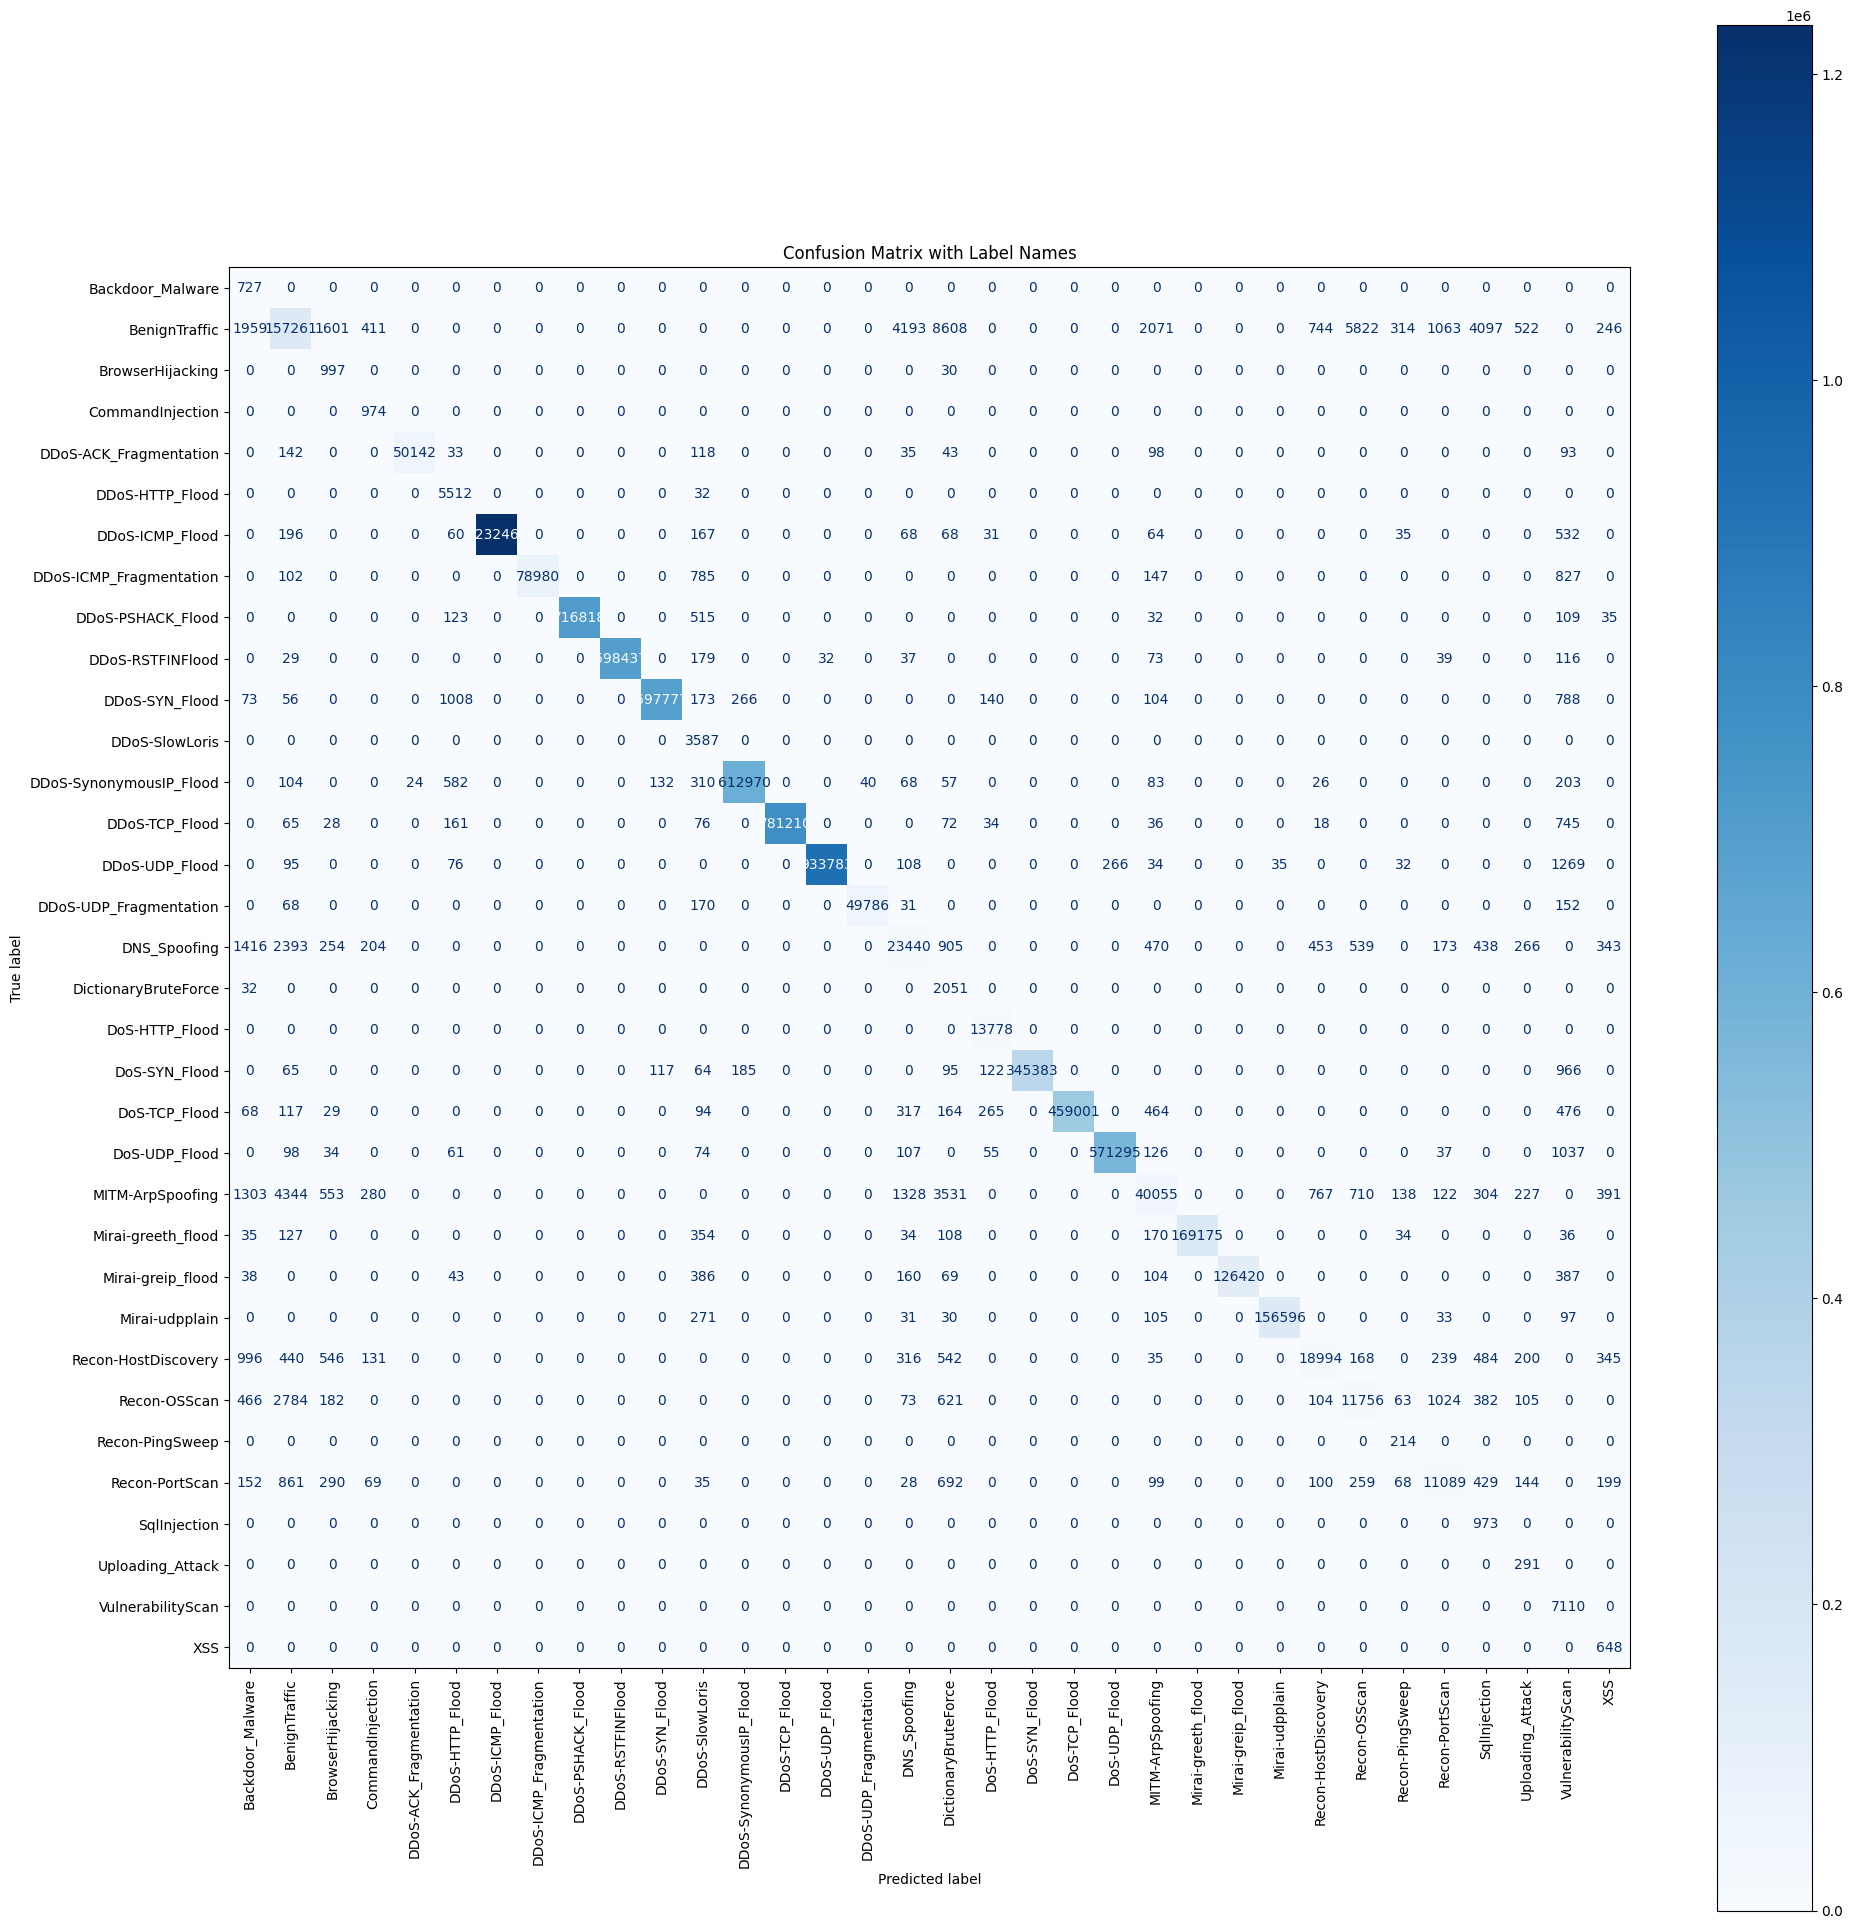

In [29]:
display_labels_names = [label_map[label] for label in np.unique(y_test)]

fig, ax = plt.subplots(figsize=(20, 20)) # Increased figure size for better readability
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', xticks_rotation='vertical')
plt.title('Confusion Matrix with Label Names')
plt.tight_layout()
plt.show()

## Random Forest Model (With Tuned Parameters)

### Hyperparameters Tuning using Randomized Search Cross Validation

I cannot tune hyperparameters for 32 million dataset, so I'm training the model on 32 million dataset and tuning it on 10% of the training sample which is 3.2 Million data row.




In [30]:
X_train_sample, _, y_train_sample, _ = train_test_split(X, y, test_size=0.9, random_state=RANDOM_STATE, stratify=y)

In [31]:
X_train_sample.shape

(4033810, 46)

In [32]:
y_train_sample.shape

(4033810,)

Set values that need to be tuned for every parameter

In [33]:
param_dist = {
    "n_estimators": [40, 60, 80],
    "max_depth": [12, 14, 16],
    "min_samples_split": [30, 50, 80],
    "min_samples_leaf": [15, 20, 30],
    "max_features": [0.25, 0.3, 0.35],
    "bootstrap": [False],
    "class_weight": ["balanced"]
}


In [34]:
random_search = RandomizedSearchCV(
    estimator=RFC_Model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    n_jobs=1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train_sample, y_train_sample)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:  1.4min
[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed:  2.8min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.0s
[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed:    6.3s finished


[CV] END bootstrap=False, class_weight=balanced, max_depth=16, max_features=0.35, min_samples_leaf=15, min_samples_split=50, n_estimators=80; total time= 3.0min


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:  1.3min
[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed:  2.9min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.0s
[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed:    6.4s finished


[CV] END bootstrap=False, class_weight=balanced, max_depth=16, max_features=0.35, min_samples_leaf=15, min_samples_split=50, n_estimators=80; total time= 3.0min


...

[CV] END bootstrap=False, class_weight=balanced, max_depth=14, max_features=0.35, min_samples_leaf=30, min_samples_split=50, n_estimators=80; total time= 3.0min


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:  1.3min
[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed:  2.8min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.1s
[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed:    6.4s finished


[CV] END bootstrap=False, class_weight=balanced, max_depth=14, max_features=0.35, min_samples_leaf=30, min_samples_split=50, n_estimators=80; total time= 3.0min


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:  1.6min
[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed:  3.5min finished


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(bootstrap=False,
                                                    class_weight='balanced',
                                                    max_depth=14,
                                                    max_features=0.3,
                                                    min_samples_leaf=20,
                                                    min_samples_split=50,
                                                    n_estimators=60, n_jobs=8,
                                                    random_state=72,
                                                    verbose=1),
                   n_jobs=1,
                   param_distributions={'bootstrap': [False],
                                        'class_weight': ['balanced'],
                                        'max_depth': [12, 14, 16],
                                        'max_features': [0.25, 0.3, 0.35],
                                        'min_samples_leaf': [15, 20, 30],
                                        'min_samples_split': [30, 50, 80],
                                        'n_estimators': [40, 60, 80]},
                   random_state=72, verbose=2)

In [35]:
best_params = random_search.best_params_
best_score = random_search.best_score_

In [36]:
best_params

{'n_estimators': 80,
 'min_samples_split': 30,
 'min_samples_leaf': 15,
 'max_features': 0.25,
 'max_depth': 16,
 'class_weight': 'balanced',
 'bootstrap': False}

### Random Forest Configuration

In [37]:
Best_RFC_Model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=8,
    verbose=1
)

print(Best_RFC_Model)

RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=16,
                       max_features=0.25, min_samples_leaf=15,
                       min_samples_split=30, n_estimators=80, n_jobs=8,
                       random_state=72, verbose=1)


### Random Forest Training

In [38]:
Best_RFC_Model.fit(X_train, y_train)
print("Training complete.")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed: 13.4min


Training complete.


[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed: 29.2min finished


### Evaluation

Apply the test dataset on the new trained model

In [39]:
y_pred = Best_RFC_Model.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   18.2s
[Parallel(n_jobs=8)]: Done  80 out of  80 | elapsed:   38.1s finished


In [40]:
overall_accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {overall_accuracy * 100:.2f}%")

Overall Accuracy: 99.44%


In [41]:
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Precision (Macro): {precision_macro * 100:.2f}%")
print(f"Precision (Weighted): {precision_weighted * 100:.2f}%")

Precision (Macro): 86.29%
Precision (Weighted): 99.58%


In [42]:
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Recall (Macro): {recall_macro * 100:.2f}%")
print(f"Recall (Weighted): {recall_weighted * 100:.2f}%")

Recall (Macro): 97.94%
Recall (Weighted): 99.44%


In [43]:
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"F1-Score (Weighted): {f1_weighted * 100:.2f}%")

F1-Score (Weighted): 99.49%


Summary

In [44]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.47      1.00      0.64       727
           1       0.95      0.91      0.93    188912
           2       0.58      1.00      0.73      1027
           3       0.73      1.00      0.85       974
           4       1.00      1.00      1.00     50704
           5       1.00      1.00      1.00      5544
           6       1.00      1.00      1.00   1233684
           7       1.00      1.00      1.00     80841
           8       1.00      1.00      1.00    717632
           9       1.00      1.00      1.00    698942
          10       1.00      1.00      1.00    700385
          11       0.57      1.00      0.72      3587
          12       1.00      1.00      1.00    614599
          13       1.00      1.00      1.00    782445
          14       1.00      1.00      1.00    935698
          15       1.00      1.00      1.00     50207
          16       0.87      0.87      0.87     31294
          17       0.19    

Let us see how many samples were correctly and incorrectly classified

In [45]:
cm = confusion_matrix(y_test, y_pred)

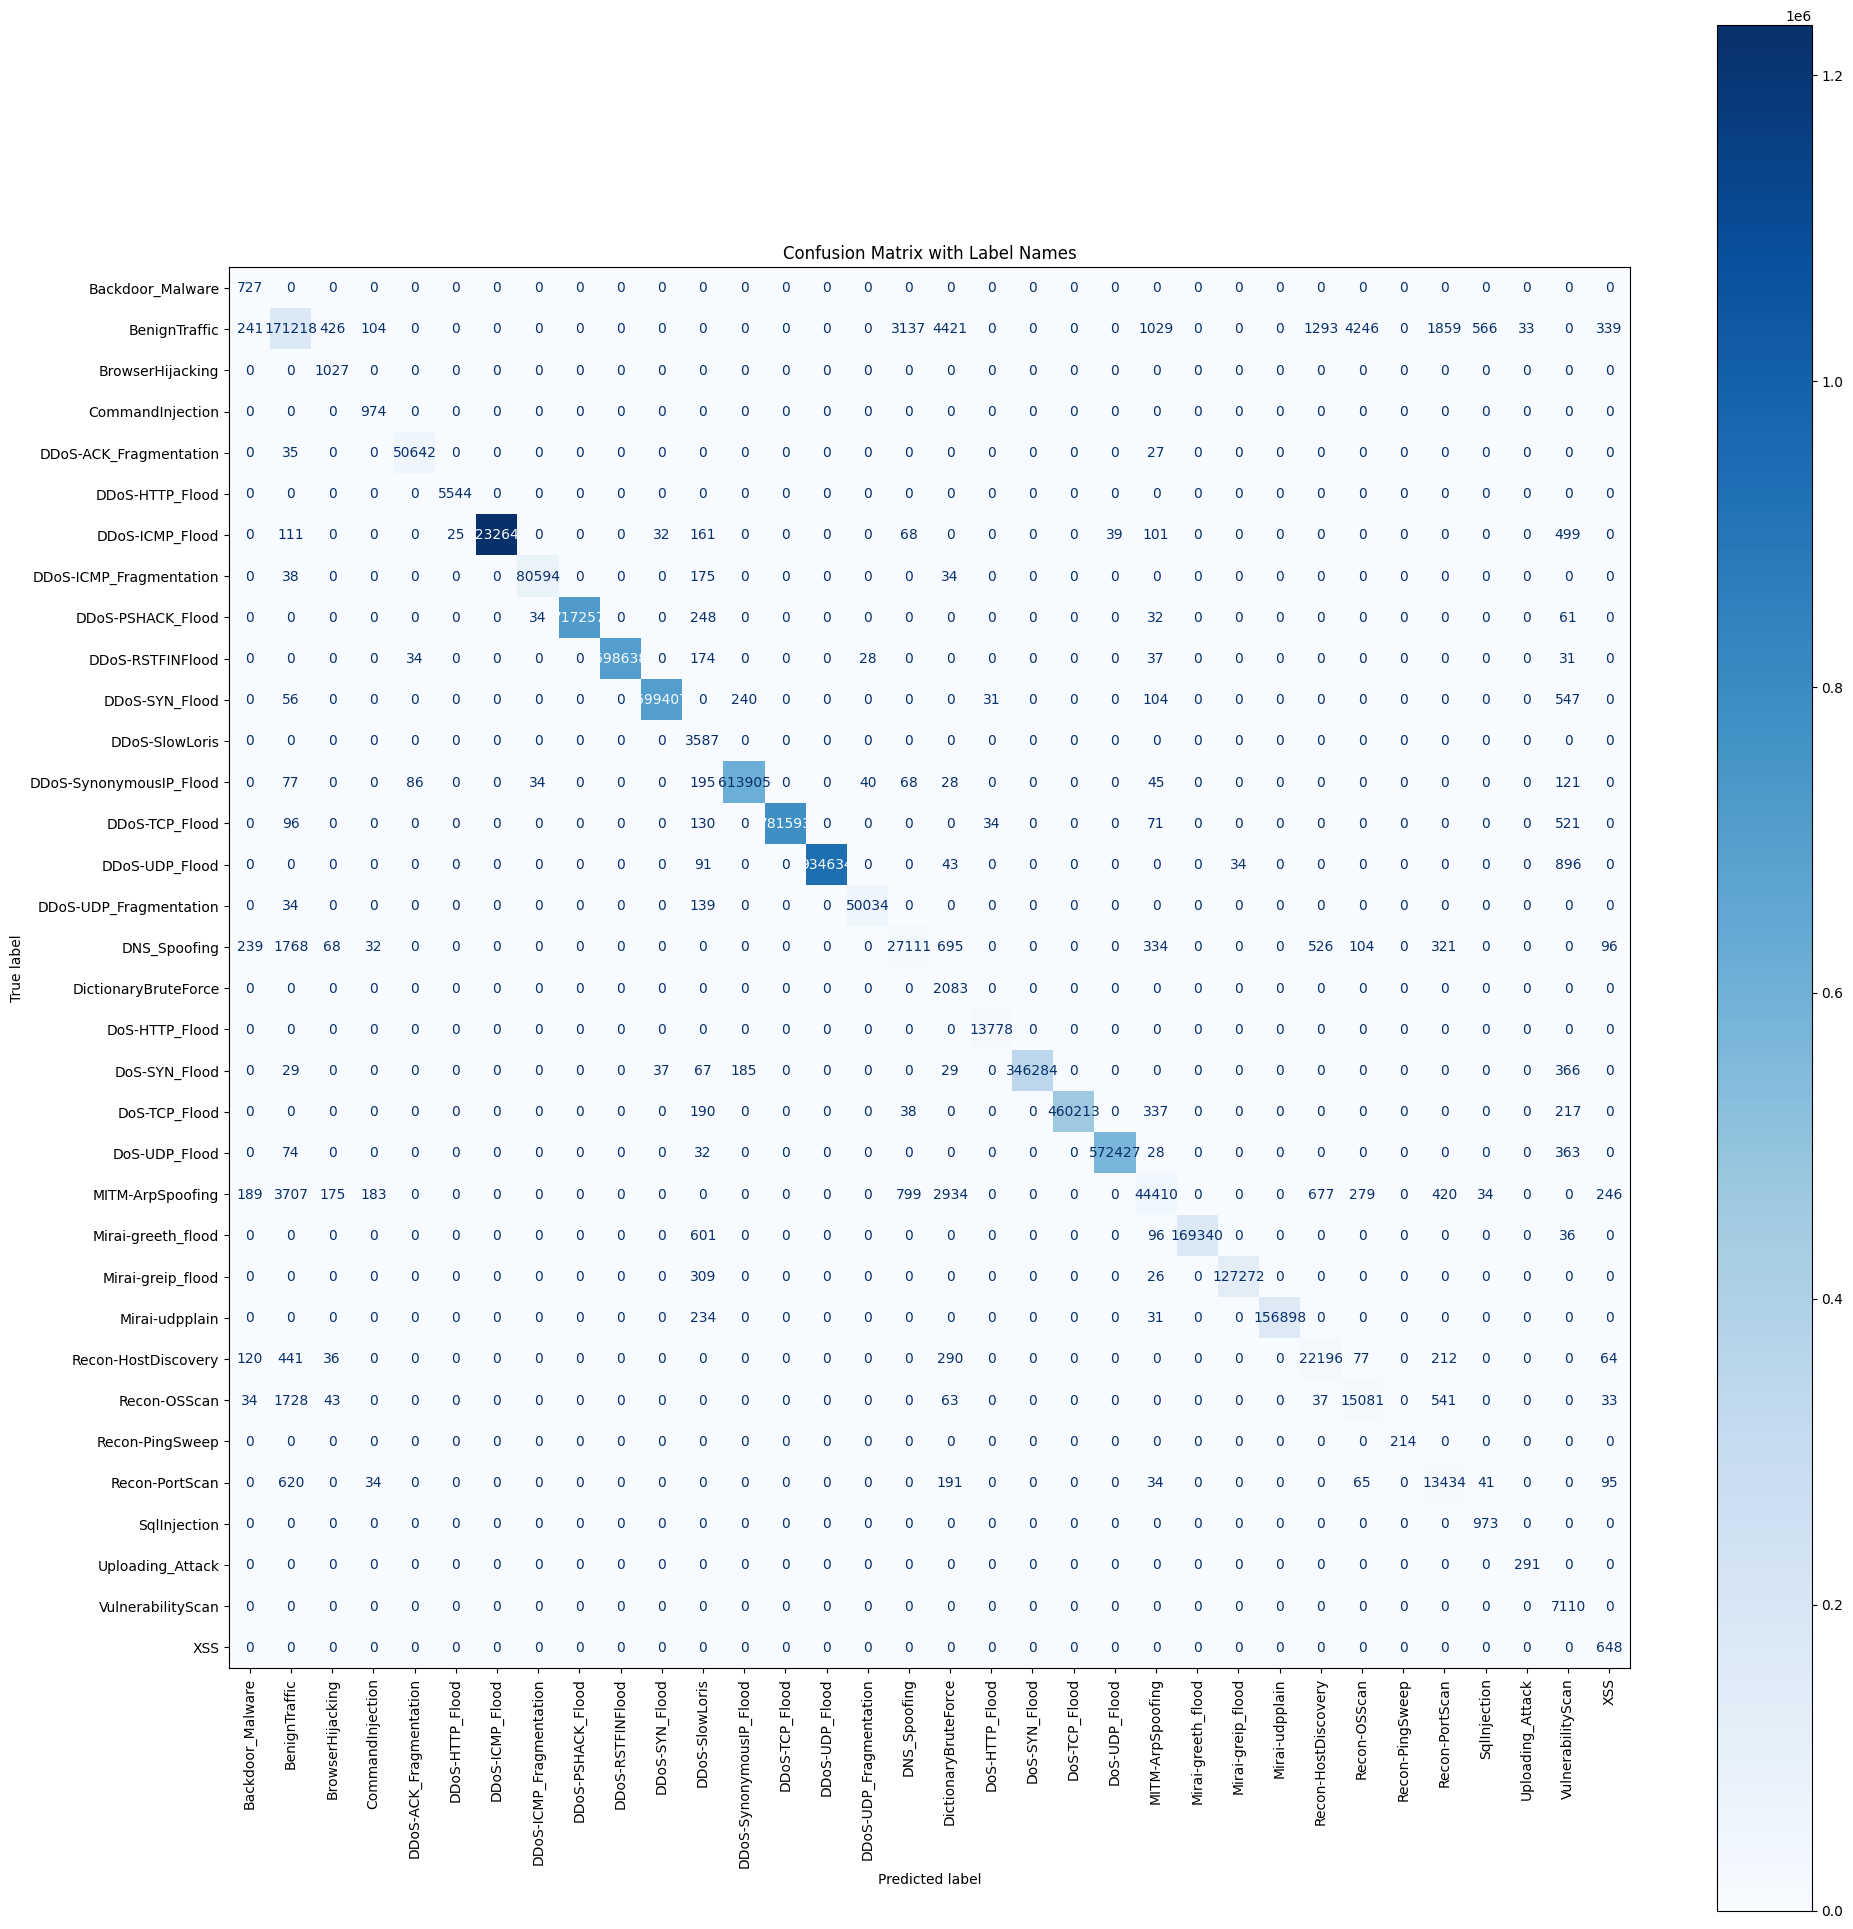

In [46]:
display_labels_names = [label_map[label] for label in np.unique(y_test)]

fig, ax = plt.subplots(figsize=(20, 20)) # Increased figure size for better readability
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', xticks_rotation='vertical')
plt.title('Confusion Matrix with Label Names')
plt.tight_layout()
plt.show()